# Soil Moisture Retrieval from Sentinel-1 SAR Data using Physics-Inspired Machine Learning

---

## Overview

This project estimates volumetric soil moisture content (SMC) from Sentinel-1 dual-polarization SAR imagery using machine learning combined with physics-inspired feature engineering.

The dataset comes from the **Texas Soil Observation Network (TxSON)**, which contains measurements from 38 in-situ monitoring stations across cropland and shrubland in central Texas. After matching Sentinel-1 acquisitions with ground observations, the final dataset contains approximately **3,347 samples** collected between **2015 and 2019**.

One of the biggest challenges in SAR-based soil moisture estimation is the effect of vegetation on the radar signal. To evaluate how well the models generalize, all experiments use **station-based cross-validation** (`GroupShuffleSplit`), ensuring that stations in the test set are never seen during training. This provides a more realistic evaluation than traditional random train-test splits.

---

## 1. Setup and Imports

**Requirements:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`,
`torch` (see `requirements.txt`).

In [1]:
# Standard library / scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR

# PyTorch (SAE + CNNR)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## 2. Data Loading

The TxSON dataset is distributed as a single Excel workbook with **one sheet per
station** (38 sheets). Each sheet contains time-stamped Sentinel-1 backscatter
(VV, VH), Sentinel-2 NDVI, and in-situ volumetric soil moisture. All sheets are
concatenated into a single dataframe with a `station` identifier column.

In [2]:
FILE_PATH = r"E:\IMPORTANT\SMC\data\36535740.xlsx"

all_sheets = pd.read_excel(FILE_PATH, sheet_name=None)
print(f"Sheets (stations) loaded: {len(all_sheets)}")

Sheets (stations) loaded: 38


In [3]:
df = pd.concat(
    [data.assign(station=sheet_name) for sheet_name, data in all_sheets.items()],
    ignore_index=True,
)
df.head()

,SN,FID,Date,VV,VH,del_VV,del_VH,NDVI,SARD1,SARD2,SARD3,SARD4,Phenology,Soil Moisture,del_SM,Rainfall,Land cover,Soil Info,inc,station
0,NaN,NaN,2015-01-01,NaN,NaN,NaN,NaN,0.370715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L_7
1,NaN,NaN,2015-01-02,NaN,NaN,NaN,NaN,0.371781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L_7
2,NaN,NaN,2015-01-03,NaN,NaN,NaN,NaN,0.372848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L_7
3,NaN,NaN,2015-01-04,NaN,NaN,NaN,NaN,0.373914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L_7
4,NaN,NaN,2015-01-05,NaN,NaN,NaN,NaN,0.374981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L_7


## 3. Data Cleaning

- Drop columns that are entirely empty.
- Drop rows missing either `VH` or `Soil Moisture` (the minimum viable observation).
- Drop pre-computed polarization-ratio columns (`SARD1–3`) and incidence angle (`inc`):
  the ratios are superseded by the physics features engineered below, and incidence
  angle was found to degrade generalization under station-grouped evaluation.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90174 entries, 0 to 90173
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   SN             0 non-null      float64       
 1   FID            0 non-null      float64       
 2   Date           90174 non-null  datetime64[us]
 3   VV             5510 non-null   float64       
 4   VH             5510 non-null   float64       
 5   del_VV         0 non-null      float64       
 6   del_VH         0 non-null      float64       
 7   NDVI           90174 non-null  float64       
 8   SARD1          5510 non-null   float64       
 9   SARD2          5510 non-null   float64       
 10  SARD3          5510 non-null   float64       
 11  SARD4          0 non-null      float64       
 12  Phenology      0 non-null      float64       
 13  Soil Moisture  63688 non-null  float64       
 14  del_SM         0 non-null      float64       
 15  Rainfall       0 non-null     

In [5]:
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=['VH', 'Soil Moisture'])
df = df.drop(columns=["SARD2", "SARD3", "inc", "SARD1"])
df.info()

<class 'pandas.DataFrame'>
Index: 3347 entries, 76 to 89497
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           3347 non-null   datetime64[us]
 1   VV             3347 non-null   float64       
 2   VH             3347 non-null   float64       
 3   NDVI           3347 non-null   float64       
 4   Soil Moisture  3347 non-null   float64       
 5   station        3347 non-null   str           
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 195.1 KB


## 4. Feature Engineering

### 4.1 Temporal Features

The day of year is encoded cyclically (sine/cosine) so that December 31 and
January 1 are adjacent in feature space, avoiding the artificial discontinuity of
a raw integer encoding.

In [6]:
# Extract month
df["month"] = pd.to_datetime(df["Date"]).dt.month

# Sort chronologically
df = df.sort_values(by='Date')

# Cyclical day-of-year encoding
df['Date'] = pd.to_datetime(df['Date'])
df['dayofyear'] = df['Date'].dt.dayofyear
df['sin_day'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['cos_day'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
df = df.drop(columns=['dayofyear'])

### 4.2 Physics-Inspired SAR Features

Two physics-inspired SAR features proposed by Bhogapurapu et al. (2022) are used to reduce the effect of vegetation on soil moisture estimation.

**DpRVIc: Dual-pol Radar Vegetation Index (corrected for GRD):**

$$
\mathrm{DpRVIc} = \frac{q(q+3)}{(q+1)^2}, \qquad q = \frac{\sigma^0_{VH}}{\sigma^0_{VV}} \;\text{(linear scale)}
$$

Ranges from 0 (bare soil) to 1 (dense vegetation) and describes the vegetation canopy
using only SAR data, without requiring optical imagery.

**Δσ: Change Detection Parameter:**

$$
\Delta\sigma = \sigma^0_{VV} - \sigma^0_{dry}
$$

where $\sigma^0_{dry}$ is the 2nd percentile of the historical VV backscatter at each
station, serving as a robust estimate of the driest observed condition. $\Delta\sigma$
captures the change in backscatter relative to this dry reference, helping separate
moisture-related changes from relatively constant factors such as terrain, soil type,
and permanent vegetation. Both linear-scale and dB-scale versions are computed.

In [7]:
# Mask valid SAR rows
mask = df['VV'].notna() & df['VH'].notna()

# Convert to linear if already in dB
# SAR backscatter in dB is usually negative; in linear scale, values are positive
if (df.loc[mask, 'VV'] < 0).any():
    VV_lin = 10 ** (df.loc[mask, 'VV'] / 10)
    VH_lin = 10 ** (df.loc[mask, 'VH'] / 10)
else:
    VV_lin = df.loc[mask, 'VV'].clip(lower=1e-10)  # already linear → stabilize
    VH_lin = df.loc[mask, 'VH'].clip(lower=1e-10)

# DpRVIc
q = VH_lin / VV_lin
df.loc[mask, 'DpRVIc'] = (q * (q + 3)) / ((q + 1) ** 2)

# Delta sigma (linear scale, per-station dry reference)
sigma_dry = df.groupby('station')['VV'].quantile(0.02)
df['sigma_dry'] = df['station'].map(sigma_dry)
df['delta_sigma'] = df['VV'] - df['sigma_dry']

# VV in dB
df.loc[mask, 'VV_dB'] = 10 * np.log10(df.loc[mask, 'VV'].clip(lower=1e-10))

# Delta sigma (dB scale, per-station dry reference) — used in the paper
sigma_dry_dB = df.groupby('station')['VV_dB'].quantile(0.02)
df['sigma_dry_dB'] = df['station'].map(sigma_dry_dB)
df['delta_sigma_dB'] = df['VV_dB'] - df['sigma_dry_dB']

### 4.3 Station-Level Soil Properties (TxSON metadata)

Clay %, Sand %, Bulk Density, and Elevation are directly measured ancillary
properties from the TxSON network metadata (Caldwell et al., 2019). These are
static per-station features — one value per station, repeated for all
observations from that station. They explain persistent inter-station
differences in soil moisture behaviour that SAR backscatter alone cannot
capture:
- **Clay %** and **Sand %**: soil texture controls water retention capacity
- **Bulk Density (BD)**: soil compaction affects porosity and drainage
- **Elevation**: topographic position influences drainage and moisture accumulation

In [8]:
# ── Load TxSON station metadata ──
meta = pd.read_csv(r"E:\IMPORTANT\SMC\data\New folder\ESSD\metadataTxSON.csv")

# Select and rename relevant columns
station_features = meta[['site_ID', 'Clay_10', 'Sand_10', 'BD', 'Elevation']].copy()
station_features = station_features.rename(columns={'site_ID': 'station'})

# Convert to numeric (some entries are 'NaN' strings)
for col in ['Clay_10', 'Sand_10', 'BD', 'Elevation']:
    station_features[col] = pd.to_numeric(station_features[col], errors='coerce')

print("Station metadata loaded:")
print(station_features.to_string())

# ── Merge into main dataframe on station name ──
df = df.merge(station_features, on='station', how='left')

print(f"\ndf shape after merge: {df.shape}")
print(f"\nMissing values in new features:")
print(df[['Clay_10', 'Sand_10', 'BD', 'Elevation']].isnull().sum())

print(f"\nFeature ranges:")
for col in ['Clay_10', 'Sand_10', 'BD', 'Elevation']:
    print(f"  {col:12s}: {df[col].min():.2f} – {df[col].max():.2f}")

print(f"\nCorrelation with Soil Moisture:")
for col in ['Clay_10', 'Sand_10', 'BD', 'Elevation']:
    r = df[col].corr(df['Soil Moisture'])
    print(f"  {col:12s}: r = {r:+.3f}")

Station metadata loaded:
   station  Clay_10  Sand_10    BD  Elevation
0      2_1      4.1     79.0  1.33        522
1      2_2      8.6     60.0  1.52        521
2      2_3     11.1     54.9  1.43        529
3      2_4     14.6     41.3  1.23        512
4      2_5      5.0     74.5  1.24        465
5      2_6     19.3     33.1  1.18        450
6      2_7      6.6     70.5  1.49        453
7      2_8     29.2     18.4  1.10        535
8      2_9     10.5     56.3  1.49        528
9     2_10      2.5     91.0  1.42        508
10    2_11      9.3     60.3  1.47        466
11    2_12     15.7     36.2  1.09        481
12    2_13     11.8     50.5  1.27        556
13    2_14      8.4     55.9  1.56        525
14    2_15     11.9     51.3  1.40        459
15    2_16     16.8     29.4  1.23        499
16    2_17     11.6     41.8  1.44        501
17    2_18      7.9     58.4  1.48        459
18    2_19     29.7     20.5  1.04        601
19    2_21      9.1     53.1  1.39        535
20    2_2

In [9]:
# ── Handle missing BD (station L_5 has no measurement) ──
bd_mean = df['BD'].mean()
n_missing = df['BD'].isnull().sum()
df['BD'] = df['BD'].fillna(bd_mean)
print(f"BD: filled {n_missing} missing values with mean = {bd_mean:.3f}")

# ── Verify no missing values remain ──
print(f"\nMissing values after imputation:")
print(df[['Clay_10','Sand_10','BD','Elevation']].isnull().sum())

print(f"\nNew df columns: {df.columns.tolist()}")

BD: filled 90 missing values with mean = 1.352

Missing values after imputation:
Clay_10      0
Sand_10      0
BD           0
Elevation    0
dtype: int64

New df columns: ['Date', 'VV', 'VH', 'NDVI', 'Soil Moisture', 'station', 'month', 'sin_day', 'cos_day', 'DpRVIc', 'sigma_dry', 'delta_sigma', 'VV_dB', 'sigma_dry_dB', 'delta_sigma_dB', 'Clay_10', 'Sand_10', 'BD', 'Elevation']


## 5. Exploratory Data Analysis

In [10]:
df.head()

,Date,VV,VH,NDVI,Soil Moisture,station,month,sin_day,cos_day,DpRVIc,sigma_dry,delta_sigma,VV_dB,sigma_dry_dB,delta_sigma_dB,Clay_10,Sand_10,BD,Elevation
0,2015-03-18,0.079214,0.015927,0.394790,0.212708,L_7,3,0.970064,0.24285,0.446172,0.051958,0.027256,-11.011982,-12.843880,1.831898,20.8,23.4,1.46,554
1,2015-03-18,0.072059,0.016075,0.651714,0.147375,2_7,3,0.970064,0.24285,0.480637,0.043270,0.028789,-11.423132,-13.638273,2.215141,6.6,70.5,1.49,453
2,2015-03-18,0.070152,0.015795,0.585526,0.233917,10_2,3,0.970064,0.24285,0.483785,0.043651,0.026502,-11.539579,-13.600096,2.060516,12.5,58.5,1.55,454
3,2015-03-18,0.058891,0.012742,0.595340,0.326208,2_6,3,0.970064,0.24285,0.470348,0.036070,0.022822,-12.299487,-14.428844,2.129356,19.3,33.1,1.18,450
4,2015-03-18,0.070579,0.015923,0.540914,0.243917,10_3,3,0.970064,0.24285,0.484471,0.046856,0.023722,-11.513271,-13.292470,1.779200,16.0,40.2,1.34,492


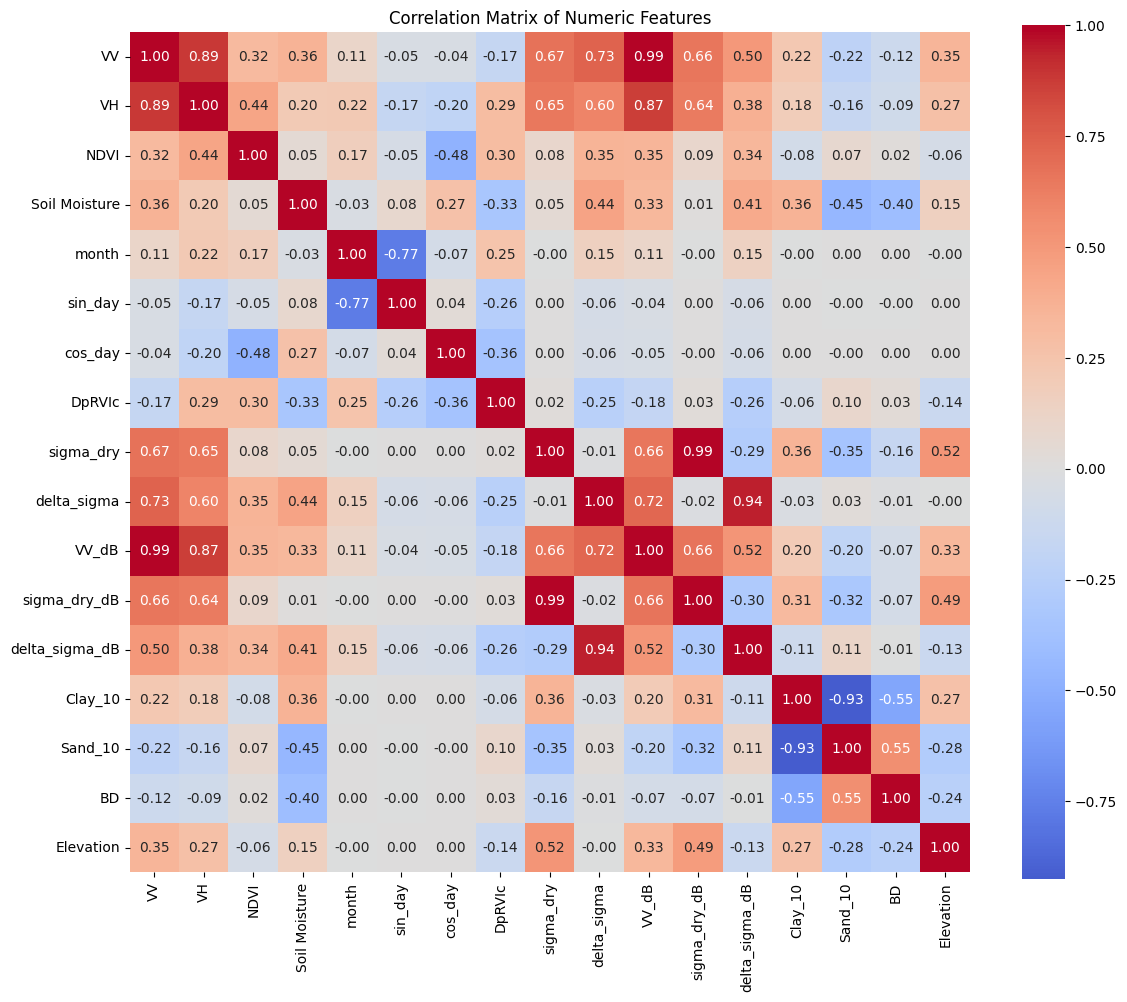

Correlations with Soil Moisture:
delta_sigma       0.443531
delta_sigma_dB    0.410019
VV                0.361476
Clay_10           0.360639
VV_dB             0.334928
cos_day           0.268136
VH                0.203063
Elevation         0.154330
sin_day           0.078003
sigma_dry         0.047922
NDVI              0.046233
sigma_dry_dB      0.014195
month            -0.033081
DpRVIc           -0.333585
BD               -0.402385
Sand_10          -0.445830
Name: Soil Moisture, dtype: float64


In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

print("Correlations with Soil Moisture:")
corr_with_target = (corr_matrix['Soil Moisture']
                    .drop('Soil Moisture')
                    .sort_values(ascending=False))
print(corr_with_target)

## 6. Exploratory Feature Importance

A Random Forest (using the final tuned hyperparameters, so the plot reflects the
production model) is fitted on a station-grouped training split to get a first look
at feature importance. `sigma_dry` / `sigma_dry_dB` are excluded here so their
per-station-constant nature does not dominate the visualization.

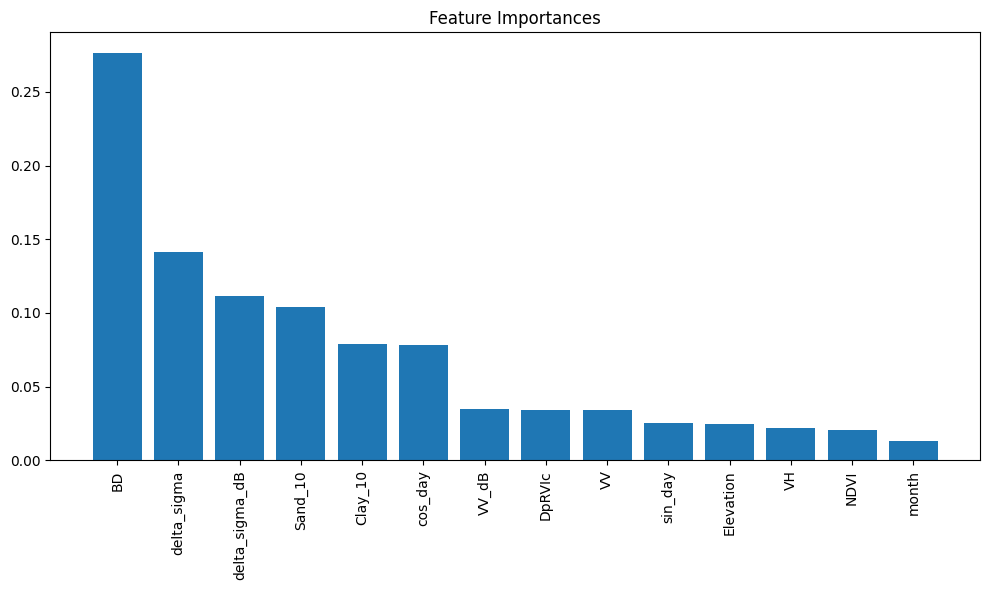

BD: 0.2766
delta_sigma: 0.1411
delta_sigma_dB: 0.1116
Sand_10: 0.1039
Clay_10: 0.0790
cos_day: 0.0782
VV_dB: 0.0348
DpRVIc: 0.0345
VV: 0.0341
sin_day: 0.0252
Elevation: 0.0249
VH: 0.0218
NDVI: 0.0208
month: 0.0133


In [12]:
X_explore = df.select_dtypes(include=[np.number]).drop(
    columns=['Soil Moisture', 'sigma_dry', 'sigma_dry_dB'], errors='ignore'
)
y_explore = df['Soil Moisture']

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X_explore, groups=df['station']))
X_train_exp = X_explore.iloc[train_idx]
y_train_exp = y_explore.iloc[train_idx]

# Use final model hyperparameters so importance plot is consistent with the trained model
rf_explore = RandomForestRegressor(
    n_estimators=100, max_depth=16, min_samples_split=10,
    min_samples_leaf=1, max_features=0.7, random_state=42
)
rf_explore.fit(X_train_exp, y_train_exp)

importances = rf_explore.feature_importances_
feature_names = X_explore.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

## 7. Modelling

### 7.1 Station-Grouped Train/Test Split

**The single most important methodological choice in this study.** A random split
lets the same station appear in both train and test, so the model can memorize
station-specific moisture baselines and report inflated scores. `GroupShuffleSplit`
by station guarantees the ~8 test stations are entirely unseen during training —
the evaluation measures true spatial generalization.

In [13]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["station"]))
train, test = df.iloc[train_idx], df.iloc[test_idx]

X_train = train.drop(columns=["Soil Moisture", "station", "Date"])
y_train = train["Soil Moisture"]
X_test = test.drop(columns=["Soil Moisture", "station", "Date"])
y_test = test["Soil Moisture"]

print(f"Train: {len(train)} samples, {train['station'].nunique()} stations")
print(f"Test:  {len(test)} samples, {test['station'].nunique()} stations")

Train: 2627 samples, 30 stations
Test:  720 samples, 8 stations


### 7.2 Feature Selection

Feature selection is performed using RFECV (Recursive Feature Elimination with
group-aware cross-validation). RFECV iteratively removes less informative
features while evaluating model performance using grouped cross-validation,
ensuring that samples from the same station are not split between training and
validation folds. This approach helps identify a compact feature set while
maintaining good generalization to unseen stations.

The final model uses the feature subset selected by RFECV.

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

cv = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='r2',
              min_features_to_select=2, n_jobs=-1, verbose=1)

rfecv.fit(X_train, y_train, groups=train['station'])

print(f"Optimal number of features: {rfecv.n_features_}")
selected_features = X_train.columns[rfecv.support_].tolist()
print(f"Selected features: {selected_features}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Optimal number of features: 6
Selected features: ['VV', 'cos_day', 'delta_sigma', 'delta_sigma_dB', 'Clay_10', 'BD']


### 7.3 Linear Regression Baseline

Fitted on the full (standardized) feature set. Serves as the floor: any model worth
its complexity must beat it.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

### 7.4 Random Forest Hyperparameter Tuning

Hyperparameters were tuned by manual sweeps with group-aware validation. Summary of
findings:

| Hyperparameter | Optimal | Behaviour |
|---|---|---|
| `min_samples_split` | 10 | Lower values overfit; higher values underfit |
| `max_depth` | 16 | Validation R² plateaus beyond 16 while training R² continues to increase |
| `n_estimators` | 100 | Performance stabilizes; adding more trees only increases computation |
| `max_features` | 0.7 | Standard column subsampling for feature decorrelation |

> Training performance increases steadily as model complexity increases, while
> validation performance improves only up to a point and then begins to decline,
> illustrating the bias-variance tradeoff.

### 7.5 Final Random Forest

In [16]:
best_n_estimators = 100
best_max_depth = 16
best_min_samples_split = 10
best_min_samples_leaf = 1
best_max_features = 0.7

rf_final = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    random_state=RANDOM_STATE,
)
rf_final.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## 8. Evaluation

Three configurations are evaluated on the held-out test stations: Linear Regression
using all features, Linear Regression using the RFECV-selected feature subset, and
the tuned Random Forest model.

In [17]:
# =========================
# 1. Linear Regression (full features)
# =========================
r2_lr_full    = r2_score(y_test, y_pred_lr)
rmse_lr_full  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr_full   = mean_absolute_error(y_test, y_pred_lr)
pearson_lr_full = np.corrcoef(y_test, y_pred_lr)[0, 1]

# =========================
# 2. Linear Regression (selected features)
# =========================
scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

lr_sel = LinearRegression()
lr_sel.fit(X_train_sel_scaled, y_train)
y_pred_lr_sel = lr_sel.predict(X_test_sel_scaled)

r2_lr_sel    = r2_score(y_test, y_pred_lr_sel)
rmse_lr_sel  = np.sqrt(mean_squared_error(y_test, y_pred_lr_sel))
mae_lr_sel   = mean_absolute_error(y_test, y_pred_lr_sel)
pearson_lr_sel = np.corrcoef(y_test, y_pred_lr_sel)[0, 1]

# =========================
# 3. Random Forest (selected features, tuned)
# =========================
y_test_pred_rf = rf_final.predict(X_test_sel)

r2_rf    = r2_score(y_test, y_test_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_rf   = mean_absolute_error(y_test, y_test_pred_rf)
pearson_rf = np.corrcoef(y_test, y_test_pred_rf)[0, 1]

# =========================
# Print results
# =========================
print("----- Linear Regression (full features) -----")
print(f"R2:      {r2_lr_full:.4f}")
print(f"RMSE:    {rmse_lr_full:.4f}")
print(f"MAE:     {mae_lr_full:.4f}")
print(f"Pearson: {pearson_lr_full:.4f}")

print("\n----- Linear Regression (selected features) -----")
print(f"R2:      {r2_lr_sel:.4f}")
print(f"RMSE:    {rmse_lr_sel:.4f}")
print(f"MAE:     {mae_lr_sel:.4f}")
print(f"Pearson: {pearson_lr_sel:.4f}")

print("\n----- Random Forest (selected features, tuned) -----")
print(f"R2:      {r2_rf:.4f}")
print(f"RMSE:    {rmse_rf:.4f}")
print(f"MAE:     {mae_rf:.4f}")
print(f"Pearson: {pearson_rf:.4f}")

----- Linear Regression (full features) -----
R2:      0.4287
RMSE:    0.0648
MAE:     0.0533
Pearson: 0.7061

----- Linear Regression (selected features) -----
R2:      0.1195
RMSE:    0.0805
MAE:     0.0683
Pearson: 0.5491

----- Random Forest (selected features, tuned) -----
R2:      0.1961
RMSE:    0.0769
MAE:     0.0658
Pearson: 0.5700


## 9. Overfitting Check

Train-vs-test comparison. A large train–test gap is expected for Random Forests
(deep trees interpolate training data); what matters is whether test performance
remains competitive.

In [18]:
# Linear Regression (full features)
y_train_pred_lr = lr.predict(X_train_scaled)
r2_lr_train   = r2_score(y_train, y_train_pred_lr)
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

# Random Forest (selected features)
y_train_pred_rf = rf_final.predict(X_train_sel)
r2_rf_train   = r2_score(y_train, y_train_pred_rf)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

print("---- Linear Regression (full features) ----")
print(f"Train R²:   {r2_lr_train:.4f}")
print(f"Test  R²:   {r2_lr_full:.4f}")
print(f"Train RMSE: {rmse_lr_train:.4f}")
print(f"Test  RMSE: {rmse_lr_full:.4f}")

print("\n---- Random Forest (selected features, tuned) ----")
print(f"Train R²:   {r2_rf_train:.4f}")
print(f"Test  R²:   {r2_rf:.4f}")
print(f"Train RMSE: {rmse_rf_train:.4f}")
print(f"Test  RMSE: {rmse_rf:.4f}")

---- Linear Regression (full features) ----
Train R²:   0.5848
Test  R²:   0.4287
Train RMSE: 0.0557
Test  RMSE: 0.0648

---- Random Forest (selected features, tuned) ----
Train R²:   0.9141
Test  R²:   0.1961
Train RMSE: 0.0253
Test  RMSE: 0.0769


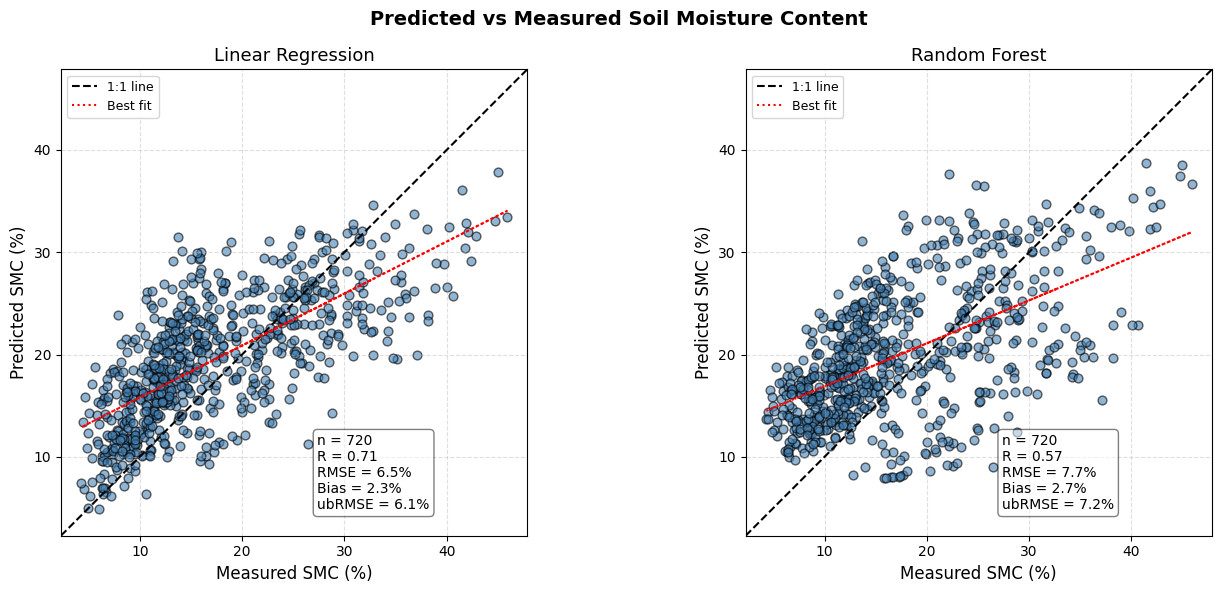

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = {
    "Linear Regression": (y_pred_lr, axes[0]),
    "Random Forest": (y_test_pred_rf, axes[1]),
}

for name, (y_pred, ax) in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    bias = np.mean(y_pred - y_test)
    ubrmse = np.sqrt(np.mean((y_pred - y_test - bias) ** 2))
    r, _ = pearsonr(y_test, y_pred)
    n = len(y_test)

    # Display in volumetric percent
    yt = np.array(y_test) * 100
    yp = np.array(y_pred) * 100

    ax.scatter(yt, yp, color='steelblue', alpha=0.6, edgecolors='k', s=40)

    lims = [min(yt.min(), yp.min()) - 2, max(yt.max(), yp.max()) + 2]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='1:1 line')

    m, b = np.polyfit(yt, yp, 1)
    ax.plot(yt, m * yt + b, 'r:', linewidth=1.5, label='Best fit')

    textstr = (f"n = {n}\nR = {r:.2f}\nRMSE = {rmse*100:.1f}%\n"
               f"Bias = {bias*100:.1f}%\nubRMSE = {ubrmse*100:.1f}%")
    ax.text(0.55, 0.05, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Measured SMC (%)", fontsize=12)
    ax.set_ylabel("Predicted SMC (%)", fontsize=12)
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Predicted vs Measured Soil Moisture Content",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("predicted_vs_measured.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. SAE Data Augmentation 

### 10a. Train Sparse Autoencoder on training stations only

Epoch  500 | total: 0.04526 | recon: 0.02160 | L1: 0.00070 | KL: 0.02296
Epoch 1000 | total: 0.03343 | recon: 0.01757 | L1: 0.00058 | KL: 0.01529
Epoch 1500 | total: 0.02249 | recon: 0.01165 | L1: 0.00049 | KL: 0.01035
Epoch 2000 | total: 0.01455 | recon: 0.00734 | L1: 0.00041 | KL: 0.00681
Epoch 2500 | total: 0.01035 | recon: 0.00578 | L1: 0.00034 | KL: 0.00424
Epoch 3000 | total: 0.00767 | recon: 0.00471 | L1: 0.00029 | KL: 0.00266


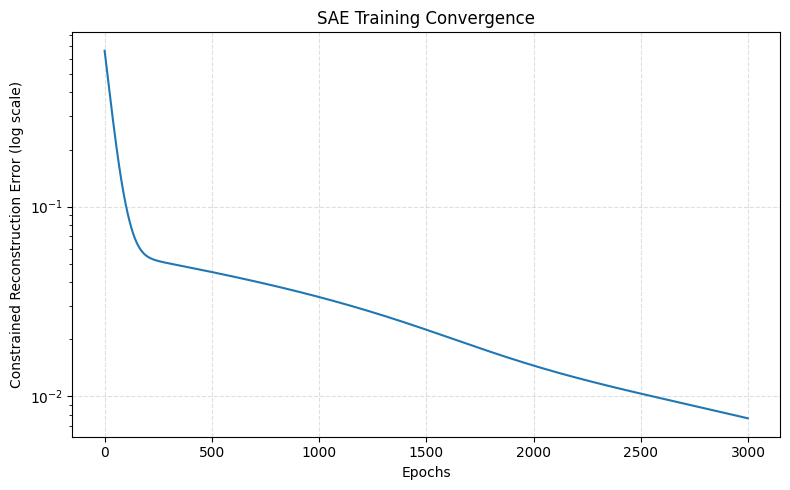


Final constrained error: 0.00767
SAE trained on 2627 training-station samples (30 stations). Test stations untouched.


In [20]:
# ── Columns the SAE reconstructs ──
# Raw observables + target ONLY. Derived features (DpRVIc, delta_sigma, VV_dB)
# are recomputed from reconstructed VV/VH afterwards, so every synthetic sample
# stays consistent with its defining physics equations.
recon_cols = ['VV', 'VH', 'NDVI', 'Soil Moisture']

# ── LEAKAGE-SAFE: fit scaler and train SAE on TRAINING stations only ──
sae_train_data = train[recon_cols].dropna()
sae_scaler = MinMaxScaler()  # sigmoid encoder expects [0, 1] inputs
X_sae = sae_scaler.fit_transform(sae_train_data)
X_sae_t = torch.tensor(X_sae, dtype=torch.float32)


class SparseAutoencoder(nn.Module):
    """Overcomplete sparse autoencoder: sigmoid encoder, linear decoder."""

    def __init__(self, n_inputs, n_hidden):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(n_inputs, n_hidden), nn.Sigmoid())
        self.decoder = nn.Linear(n_hidden, n_inputs)

    def forward(self, x):
        h = self.encoder(x)
        return self.decoder(h), h


def kl_divergence(rho, rho_hat):
    """KL divergence between target sparsity rho and observed activations."""
    rho_hat = torch.clamp(rho_hat, 1e-7, 1 - 1e-7)
    return torch.sum(rho * torch.log(rho / rho_hat)
                     + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat)))


# Hyperparameters: capacity prioritized over sparsity. The paper's settings
# (h=8, lambda=1e-3, beta=0.05) collapsed reconstructions toward the mean on
# this dataset; the values below preserve the joint feature structure.
n_inputs = len(recon_cols)
n_hidden = 16
lam = 1e-4      # L1 coefficient
beta = 5e-3     # KL coefficient
rho = 0.10      # target sparsity level
n_epochs = 3000

sae = SparseAutoencoder(n_inputs, n_hidden)
optimizer = torch.optim.Adam(sae.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()

loss_history = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    x_hat, h = sae(X_sae_t)

    recon_err = mse_loss(x_hat, X_sae_t)
    l1_term = lam * torch.mean(torch.sum(torch.abs(h), dim=1))
    rho_hat = torch.mean(h, dim=0)
    kl_term = beta * kl_divergence(torch.tensor(rho), rho_hat)

    loss = recon_err + l1_term + kl_term  # E_c = E + L1 + KLD
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | total: {loss.item():.5f} | "
              f"recon: {recon_err.item():.5f} | L1: {l1_term.item():.5f} | "
              f"KL: {kl_term.item():.5f}")

plt.figure(figsize=(8, 5))
plt.semilogy(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Constrained Reconstruction Error (log scale)")
plt.title("SAE Training Convergence")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nFinal constrained error: {loss_history[-1]:.5f}")
print(f"SAE trained on {len(sae_train_data)} training-station samples "
      f"({train['station'].nunique()} stations). Test stations untouched.")

### Sparse Autoencoder (SAE) Data Augmentation

The dataset contains only **~3,347 matched Sentinel-1 and ground soil moisture observations**, which is relatively small for training machine learning models. To increase the amount of training data without collecting additional field measurements, a **Sparse Autoencoder (SAE)** is used to generate synthetic samples.

An autoencoder consists of two parts:

- **Encoder:** Compresses the input features into a lower-dimensional representation.
- **Decoder:** Reconstructs the original sample from this compressed representation.

Since the model learns the underlying patterns in the data rather than memorizing individual samples, the reconstructed outputs serve as realistic synthetic training data. Sparsity is enforced using **L1 regularization** and a **KL-divergence penalty**, encouraging the network to learn compact and informative feature representations.

### Leakage-safe Training

The autoencoder is trained **only on the training stations**, ensuring that samples from the held-out test stations are never used during augmentation. This prevents data leakage and provides a fair evaluation of the model's ability to generalize to unseen locations.

The training loss decreases rapidly during the initial epochs before gradually converging, indicating successful learning of the underlying data distribution.

### 10b. Generate Synthetic Samples, Recompute Physics Features, and Validate

The trained SAE reconstructs each training sample once, effectively doubling the
training dataset, following the approach described in the paper. Instead of
reconstructing the derived physics features directly, they are **recomputed** from
the reconstructed VV and VH backscatter values. This ensures that every synthetic
sample satisfies the DpRVIc and Δσ equations exactly.

Before the synthetic samples are used for model training, they must pass three
validation checks:

1. **Distribution Check:** The feature distributions of the synthetic data should
   closely match those of the original training data.
2. **Physical Plausibility:** All reconstructed values must remain within realistic
   physical ranges.
3. **Correlation Preservation:** The relationships between key variables, especially
   VV–Soil Moisture and Δσ–Soil Moisture, should be preserved.

Only after passing these checks are the synthetic samples combined with the original
training data.

GATE 2 — Physical plausibility: dropped 0/2627 (0.0%) implausible synthetic samples


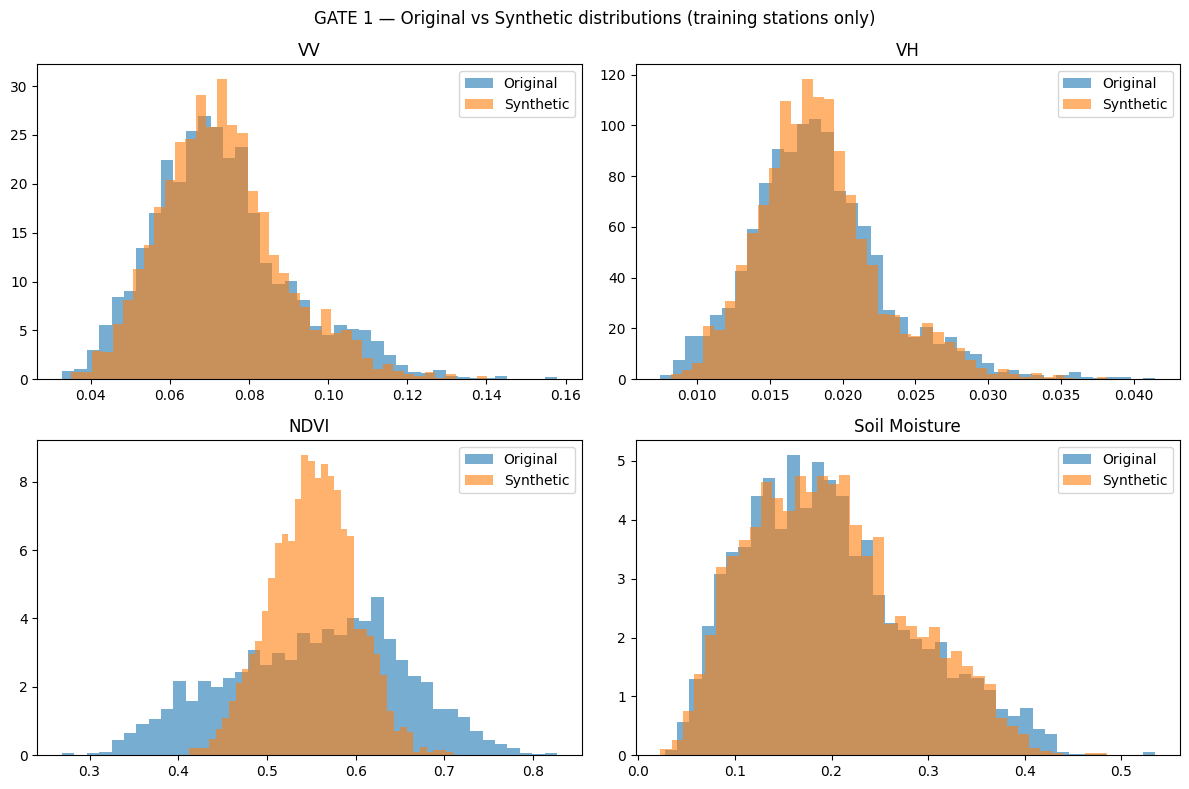


GATE 3 — Correlation with Soil Moisture (original vs synthetic):
  VV               orig: +0.365   synth: +0.311   |diff|: 0.054
  VH               orig: +0.199   synth: +0.227   |diff|: 0.028
  NDVI             orig: +0.055   synth: +0.139   |diff|: 0.085
  DpRVIc           orig: -0.348   synth: -0.510   |diff|: 0.162
  delta_sigma      orig: +0.456   synth: +0.339   |diff|: 0.117
  delta_sigma_dB   orig: +0.427   synth: +0.328   |diff|: 0.099

Max |correlation difference| across all pairs: 0.627


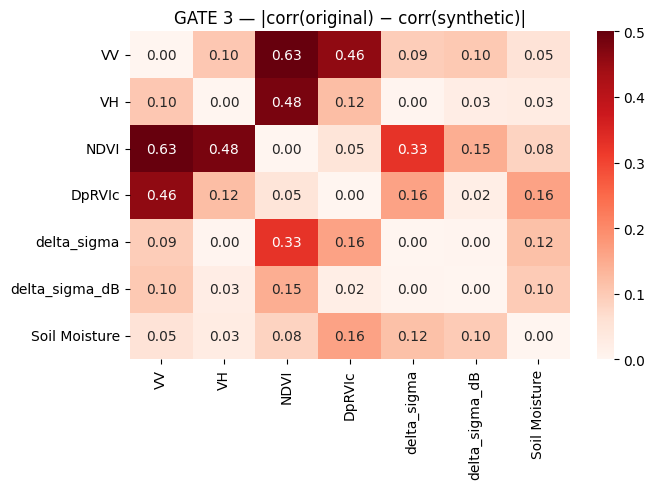


Synthetic samples ready: 2627 (from 2627 originals, 30 training stations)


In [21]:
# ── 1. Reconstruct the training samples ──
sae.eval()
with torch.no_grad():
    X_recon_scaled, _ = sae(X_sae_t)
X_recon = sae_scaler.inverse_transform(X_recon_scaled.numpy())

# Build synthetic frame aligned to the ORIGINAL train rows (same index)
synth = pd.DataFrame(X_recon, columns=recon_cols, index=sae_train_data.index)

# ── 2. Copy unchanged columns from the parent samples ──
carry_cols = ['station', 'Date', 'month', 'sin_day', 'cos_day',
              'sigma_dry', 'sigma_dry_dB', 'Clay_10', 'Sand_10', 'BD', 'Elevation']
for c in carry_cols:
    synth[c] = train.loc[synth.index, c].values

# ── 3. Recompute derived features from reconstructed VV/VH (same equations as Section 4.2) ──
VV_lin_s = synth['VV'].clip(lower=1e-10)     # training data is linear scale
VH_lin_s = synth['VH'].clip(lower=1e-10)

q_s = VH_lin_s / VV_lin_s
synth['DpRVIc'] = (q_s * (q_s + 3)) / ((q_s + 1) ** 2)

synth['VV_dB']          = 10 * np.log10(VV_lin_s)
synth['delta_sigma']    = synth['VV']    - synth['sigma_dry']
synth['delta_sigma_dB'] = synth['VV_dB'] - synth['sigma_dry_dB']

# ── GATE 2: physical plausibility filter ──
n_before = len(synth)
plausible = (
    (synth['Soil Moisture'] >= 0.0) & (synth['Soil Moisture'] <= 0.55) &
    (synth['VV'] > 0) & (synth['VH'] > 0) &
    (synth['DpRVIc'] >= 0) & (synth['DpRVIc'] <= 1)
)
synth = synth[plausible]
n_dropped = n_before - len(synth)
print(f"GATE 2 — Physical plausibility: dropped {n_dropped}/{n_before} "
      f"({100*n_dropped/n_before:.1f}%) implausible synthetic samples")

# ── GATE 1: marginal distributions (paper's Figure 11 equivalent) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), recon_cols):
    ax.hist(sae_train_data[col], bins=40, alpha=0.6, label='Original', density=True)
    ax.hist(synth[col],          bins=40, alpha=0.6, label='Synthetic', density=True)
    ax.set_title(col); ax.legend()
plt.suptitle("GATE 1 — Original vs Synthetic distributions (training stations only)")
plt.tight_layout()
plt.show()

# ── GATE 3: correlation-structure preservation ──
check_cols = ['VV', 'VH', 'NDVI', 'DpRVIc', 'delta_sigma',
              'delta_sigma_dB', 'Soil Moisture']
corr_orig  = train.loc[sae_train_data.index, check_cols].corr()
corr_synth = synth[check_cols].corr()
corr_diff  = (corr_orig - corr_synth).abs()

print("\nGATE 3 — Correlation with Soil Moisture (original vs synthetic):")
for c in check_cols[:-1]:
    print(f"  {c:15s}  orig: {corr_orig.loc[c,'Soil Moisture']:+.3f}   "
          f"synth: {corr_synth.loc[c,'Soil Moisture']:+.3f}   "
          f"|diff|: {corr_diff.loc[c,'Soil Moisture']:.3f}")
print(f"\nMax |correlation difference| across all pairs: {corr_diff.values.max():.3f}")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=0.5)
plt.title("GATE 3 — |corr(original) − corr(synthetic)|")
plt.tight_layout()
plt.show()

print(f"\nSynthetic samples ready: {len(synth)} "
      f"(from {len(sae_train_data)} originals, {synth['station'].nunique()} training stations)")

### 10c. Experiment 2 — Retrain Random Forest on augmented data

The augmented training set = real training samples + SAE-reconstructed synthetic
samples (training stations only). Model configuration, selected features, and the
real held-out test stations are identical to Experiment 1. The ONLY change is
the training data, so any performance difference is attributable to augmentation.

In [22]:
# ── 1. Build augmented training set ──
feature_cols = selected_features                     # same RFECV features as Exp 1

X_train_aug = pd.concat([X_train_sel, synth[feature_cols]], ignore_index=True)
y_train_aug = pd.concat([y_train,     synth['Soil Moisture']], ignore_index=True)

print(f"Real training samples     : {len(X_train_sel)}")
print(f"Synthetic training samples: {len(synth)}")
print(f"Augmented training total  : {len(X_train_aug)}")
print(f"Test set (REAL only)      : {len(X_test_sel)} samples — unchanged")

# ── 2. Retrain identical RF configuration on augmented data ──
rf_aug = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    random_state=42
)
rf_aug.fit(X_train_aug, y_train_aug)

# ── 3. Evaluate on the SAME real test stations ──
y_test_pred_aug = rf_aug.predict(X_test_sel)

r2_aug      = r2_score(y_test, y_test_pred_aug)
rmse_aug    = np.sqrt(mean_squared_error(y_test, y_test_pred_aug))
mae_aug     = mean_absolute_error(y_test, y_test_pred_aug)
pearson_aug = np.corrcoef(y_test, y_test_pred_aug)[0, 1]

print("\n================ COMPARISON ================")
print(f"{'Metric':<12}{'Exp 1 (original)':<20}{'Exp 2 (augmented)':<20}")
print(f"{'RMSE':<12}{rmse_rf:<20.4f}{rmse_aug:<20.4f}")
print(f"{'MAE':<12}{mae_rf:<20.4f}{mae_aug:<20.4f}")
print(f"{'Pearson r':<12}{pearson_rf:<20.4f}{pearson_aug:<20.4f}")
print(f"{'R²':<12}{r2_rf:<20.4f}{r2_aug:<20.4f}")

Real training samples     : 2627
Synthetic training samples: 2627
Augmented training total  : 5254
Test set (REAL only)      : 720 samples — unchanged

================ COMPARISON ================
Metric      Exp 1 (original)    Exp 2 (augmented)   
RMSE        0.0769              0.0754              
MAE         0.0658              0.0647              
Pearson r   0.5700              0.5777              
R²          0.1961              0.2271              


### Analysis — Experiment 2 (Single Split)

Representative results from the primary configuration (physics features, seed-42
partition):

| Metric | Original | SAE-Augmented |
|--------|----------|---------------|
| RMSE (m³/m³) | 0.0769 | 0.0754 |
| MAE (m³/m³) | 0.0658 | 0.0647 |
| Pearson r | 0.5700 | 0.5777 |
| R² | 0.1961 | 0.2271 |

The SAE-augmented model shows a consistent, though modest, improvement over the
original model. RMSE and MAE decrease slightly, while both Pearson correlation and
R² increase, indicating better predictive performance and improved agreement with
the observed soil moisture values.

The improvement is relatively small because the original training set already
contains over 2,600 real samples, providing substantial coverage of the feature
space. The synthetic samples generated by the autoencoder mainly reinforce existing
patterns rather than introducing entirely new information. In addition, the
augmentation procedure is leakage-safe, as the SAE is trained only on the training
stations and never uses samples from the held-out test stations. This ensures that
the reported performance reflects genuine generalization to unseen locations rather
than information leakage.

### 10d. Ablation — Gaussian Noise Baseline vs SAE Augmentation

To determine whether the improvements come from the SAE's learned representations
or simply from adding variability to the training data, a second augmentation
strategy is evaluated using Gaussian noise. Synthetic samples are created by adding
random Gaussian noise to the same variables reconstructed by the SAE.

The noise level for each variable is matched to the average reconstruction error of
the SAE so that both methods introduce a similar amount of perturbation. The key
difference is that the SAE generates structured samples by learning relationships
within the data, whereas Gaussian noise perturbs each feature independently.

The Gaussian-augmented samples undergo the same plausibility checks, physics feature
recomputation, Random Forest training, and evaluation on the same held-out test
stations, ensuring a fair comparison between the two augmentation methods.

In [23]:
rng = np.random.default_rng(RANDOM_STATE)

# ── 1. Match noise scale to the SAE's actual perturbation per variable ──
# (std of reconstruction deviation, computed in real units)
sae_deviation = synth[recon_cols].values - sae_train_data.loc[synth.index, recon_cols].values
noise_scale = sae_deviation.std(axis=0)

print("Noise scale per variable (matched to SAE deviation):")
for c, s in zip(recon_cols, noise_scale):
    print(f"  {c:15s} σ = {s:.5f}")

# ── 2. Generate noise-based synthetic samples ──
noise_synth = sae_train_data.copy()
noise_synth[recon_cols] = noise_synth[recon_cols].values + \
    rng.normal(0, noise_scale, size=noise_synth[recon_cols].shape)

# Carry over unchanged columns from parent samples
for c in carry_cols:
    noise_synth[c] = train.loc[noise_synth.index, c].values

# ── 3. Recompute derived features (same equations as before) ──
VV_lin_n = noise_synth['VV'].clip(lower=1e-10)
VH_lin_n = noise_synth['VH'].clip(lower=1e-10)
q_n = VH_lin_n / VV_lin_n
noise_synth['DpRVIc']         = (q_n * (q_n + 3)) / ((q_n + 1) ** 2)
noise_synth['VV_dB']          = 10 * np.log10(VV_lin_n)
noise_synth['delta_sigma']    = noise_synth['VV']    - noise_synth['sigma_dry']
noise_synth['delta_sigma_dB'] = noise_synth['VV_dB'] - noise_synth['sigma_dry_dB']

# ── 4. Same plausibility filter ──
n_before = len(noise_synth)
plausible_n = (
    (noise_synth['Soil Moisture'] >= 0.0) & (noise_synth['Soil Moisture'] <= 0.55) &
    (noise_synth['VV'] > 0) & (noise_synth['VH'] > 0) &
    (noise_synth['DpRVIc'] >= 0) & (noise_synth['DpRVIc'] <= 1)
)
noise_synth = noise_synth[plausible_n]
print(f"\nPlausibility filter: dropped {n_before - len(noise_synth)}/{n_before} "
      f"({100*(n_before - len(noise_synth))/n_before:.1f}%)")

# Quick correlation sanity check (target column only)
print("\nCorrelation with Soil Moisture (original vs noise-synthetic):")
for c in ['VV', 'delta_sigma', 'DpRVIc']:
    orig_r  = train.loc[sae_train_data.index, [c, 'Soil Moisture']].corr().iloc[0, 1]
    noise_r = noise_synth[[c, 'Soil Moisture']].corr().iloc[0, 1]
    print(f"  {c:15s} orig: {orig_r:+.3f}   noise-synth: {noise_r:+.3f}")

# ── 5. Train identical RF on noise-augmented data ──
X_train_noise = pd.concat([X_train_sel, noise_synth[feature_cols]], ignore_index=True)
y_train_noise = pd.concat([y_train,     noise_synth['Soil Moisture']], ignore_index=True)

rf_noise = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    random_state=42
)
rf_noise.fit(X_train_noise, y_train_noise)
y_test_pred_noise = rf_noise.predict(X_test_sel)

r2_noise      = r2_score(y_test, y_test_pred_noise)
rmse_noise    = np.sqrt(mean_squared_error(y_test, y_test_pred_noise))
mae_noise     = mean_absolute_error(y_test, y_test_pred_noise)
pearson_noise = np.corrcoef(y_test, y_test_pred_noise)[0, 1]

# ── 6. Three-way comparison ──
print("\n================== THREE-WAY COMPARISON ==================")
print(f"{'Metric':<12}{'Original':<15}{'SAE-augmented':<18}{'Noise-augmented':<18}")
print(f"{'RMSE':<12}{rmse_rf:<15.4f}{rmse_aug:<18.4f}{rmse_noise:<18.4f}")
print(f"{'MAE':<12}{mae_rf:<15.4f}{mae_aug:<18.4f}{mae_noise:<18.4f}")
print(f"{'Pearson r':<12}{pearson_rf:<15.4f}{pearson_aug:<18.4f}{pearson_noise:<18.4f}")
print(f"{'R²':<12}{r2_rf:<15.4f}{r2_aug:<18.4f}{r2_noise:<18.4f}")

Noise scale per variable (matched to SAE deviation):
  VV              σ = 0.00601
  VH              σ = 0.00106
  NDVI            σ = 0.06844
  Soil Moisture   σ = 0.01132

Plausibility filter: dropped 0/2627 (0.0%)

Correlation with Soil Moisture (original vs noise-synthetic):
  VV              orig: +0.365   noise-synth: +0.344
  delta_sigma     orig: +0.456   noise-synth: +0.409
  DpRVIc          orig: -0.348   noise-synth: -0.263

================== THREE-WAY COMPARISON ==================
Metric      Original       SAE-augmented     Noise-augmented   
RMSE        0.0769         0.0754            0.0730            
MAE         0.0658         0.0647            0.0628            
Pearson r   0.5700         0.5777            0.5991            
R²          0.1961         0.2271            0.2754            


### Analysis — Noise Ablation (Single Split)

| Metric | Original | SAE-Augmented | Noise-Augmented |
|--------|----------|---------------|-----------------|
| RMSE (m³/m³) | 0.0769 | 0.0754 | **0.0730** |
| MAE (m³/m³) | 0.0658 | 0.0647 | **0.0628** |
| Pearson r | 0.5700 | 0.5777 | **0.5991** |
| R² | 0.1961 | 0.2271 | **0.2754** |

For this train-test split, Gaussian noise augmentation achieved the best performance
across all evaluation metrics, outperforming both the original model and the
SAE-augmented model. This suggests that, for this dataset, introducing additional
variability through simple random perturbations was more beneficial than generating
structured synthetic samples with the autoencoder.

The comparison is based on the same training procedure, plausibility filtering,
recomputed physics-inspired features, and evaluation on the same held-out test
stations, making the results directly comparable. However, since these findings are
based on a single split, a multi-seed robustness analysis is performed next to
determine whether the observed improvements are consistent across different
train-test partitions.

### 10e. Robustness Check — Repeated Station Partitions

To evaluate whether the observed results are consistent, the three-way comparison is
repeated across multiple `GroupShuffleSplit` seeds, each producing a different
train-test station partition. For every split, the SAE is trained from scratch
using only the training stations, synthetic samples are regenerated, physics
features are recomputed, and the same plausibility checks are applied. The Gaussian
noise baseline is also regenerated by matching its noise scale to the SAE
reconstruction error for that split, ensuring a fair comparison.

To keep the computational cost manageable, the RFECV-selected feature subset from
the primary split is used for all repeated experiments. This is a minor
simplification but allows the robustness analysis to focus on the effect of data
augmentation across different station partitions.

In [24]:
def train_sae(X_scaled_t, n_inputs, n_hidden=16, lam=1e-4, beta=5e-3,
              rho=0.10, n_epochs=3000, seed=42):
    """Train a fresh SAE (used per-split in the robustness loop)."""
    torch.manual_seed(seed)
    model = SparseAutoencoder(n_inputs, n_hidden)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()
    for _ in range(n_epochs):
        opt.zero_grad()
        x_hat, h = model(X_scaled_t)
        rho_hat = torch.mean(h, dim=0)
        loss = (mse(x_hat, X_scaled_t)
                + lam * torch.mean(torch.sum(torch.abs(h), dim=1))
                + beta * kl_divergence(torch.tensor(rho), rho_hat))
        loss.backward()
        opt.step()
    return model


def recompute_physics(df_s):
    """Recompute derived features from (possibly synthetic) VV/VH."""
    vv = df_s['VV'].clip(lower=1e-10)
    vh = df_s['VH'].clip(lower=1e-10)
    q = vh / vv
    df_s['DpRVIc'] = (q * (q + 3)) / ((q + 1) ** 2)
    df_s['VV_dB'] = 10 * np.log10(vv)
    df_s['delta_sigma'] = df_s['VV'] - df_s['sigma_dry']
    df_s['delta_sigma_dB'] = df_s['VV_dB'] - df_s['sigma_dry_dB']
    return df_s


def plausible_mask(df_s):
    """Physical plausibility filter for synthetic samples."""
    return ((df_s['Soil Moisture'] >= 0) & (df_s['Soil Moisture'] <= 0.55)
            & (df_s['VV'] > 0) & (df_s['VH'] > 0)
            & (df_s['DpRVIc'] >= 0) & (df_s['DpRVIc'] <= 1))


def make_rf():
    return RandomForestRegressor(
        n_estimators=best_n_estimators, max_depth=best_max_depth,
        min_samples_split=best_min_samples_split,
        min_samples_leaf=best_min_samples_leaf,
        max_features=best_max_features, random_state=RANDOM_STATE)


def evaluate(model, X_te, y_te):
    p = model.predict(X_te)
    return dict(rmse=np.sqrt(mean_squared_error(y_te, p)),
                mae=mean_absolute_error(y_te, p),
                r=np.corrcoef(y_te, p)[0, 1],
                r2=r2_score(y_te, p))


seeds = [42, 7, 123, 2024, 555, 1, 99, 300]
results = {cfg: [] for cfg in ['original', 'sae', 'noise']}

for seed in seeds:
    # Fresh station partition
    gss_s = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=seed)
    tr_idx, te_idx = next(gss_s.split(df, groups=df['station']))
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]

    X_tr = tr[selected_features]
    y_tr = tr['Soil Moisture']
    X_te = te[selected_features]
    y_te = te['Soil Moisture']

    # SAE retrained from scratch on THIS split's training stations
    sae_data = tr[recon_cols].dropna()
    scaler_s = MinMaxScaler()
    Xs = torch.tensor(scaler_s.fit_transform(sae_data), dtype=torch.float32)
    sae_s = train_sae(Xs, len(recon_cols), seed=seed)
    sae_s.eval()
    with torch.no_grad():
        Xr, _ = sae_s(Xs)
    syn = pd.DataFrame(scaler_s.inverse_transform(Xr.numpy()),
                       columns=recon_cols, index=sae_data.index)
    for c in carry_cols:
        syn[c] = tr.loc[syn.index, c].values
    syn = recompute_physics(syn)
    syn = syn[plausible_mask(syn)]

    # Noise: scale matched to THIS split's SAE deviation
    dev = syn[recon_cols].values - sae_data.loc[syn.index, recon_cols].values
    scale = dev.std(axis=0)
    rng_s = np.random.default_rng(seed)
    nsyn = sae_data.copy()
    nsyn[recon_cols] = (nsyn[recon_cols].values
                        + rng_s.normal(0, scale, size=nsyn[recon_cols].shape))
    for c in carry_cols:
        nsyn[c] = tr.loc[nsyn.index, c].values
    nsyn = recompute_physics(nsyn)
    nsyn = nsyn[plausible_mask(nsyn)]

    # Three RF configurations
    configs = {
        'original': (X_tr, y_tr),
        'sae': (pd.concat([X_tr, syn[selected_features]], ignore_index=True),
                pd.concat([y_tr, syn['Soil Moisture']], ignore_index=True)),
        'noise': (pd.concat([X_tr, nsyn[selected_features]], ignore_index=True),
                  pd.concat([y_tr, nsyn['Soil Moisture']], ignore_index=True)),
    }
    row = {}
    for name, (Xa, ya) in configs.items():
        rf_s = make_rf()
        rf_s.fit(Xa, ya)
        m = evaluate(rf_s, X_te, y_te)
        results[name].append(m)
        row[name] = m['r']
    print(f"seed {seed:4d} | r  orig: {row['original']:.4f}  "
          f"sae: {row['sae']:.4f}  noise: {row['noise']:.4f}")

# Summary: mean +/- std across seeds
print(f"\n========== ROBUSTNESS SUMMARY ({len(seeds)} seeds) ==========")
print(f"{'Metric':<10}{'Original':<20}{'SAE-aug':<20}{'Noise-aug':<20}")
for metric in ['rmse', 'mae', 'r', 'r2']:
    line = f"{metric:<10}"
    for cfg in ['original', 'sae', 'noise']:
        vals = np.array([m[metric] for m in results[cfg]])
        line += f"{vals.mean():.4f} ± {vals.std():.4f}   "
    print(line)

# Per-seed winner count (by Pearson r)
wins = {c: 0 for c in results}
for i in range(len(seeds)):
    rs = {c: results[c][i]['r'] for c in results}
    wins[max(rs, key=rs.get)] += 1
print(f"\nWins by Pearson r across seeds: {wins}")

seed   42 | r  orig: 0.5700  sae: 0.5777  noise: 0.5991
seed    7 | r  orig: 0.6601  sae: 0.6695  noise: 0.6818
seed  123 | r  orig: 0.8536  sae: 0.8475  noise: 0.8498
seed 2024 | r  orig: 0.8304  sae: 0.8151  noise: 0.8226
seed  555 | r  orig: 0.6308  sae: 0.6287  noise: 0.6319
seed    1 | r  orig: 0.7899  sae: 0.7982  noise: 0.7927
seed   99 | r  orig: 0.9037  sae: 0.8939  noise: 0.9019
seed  300 | r  orig: 0.6973  sae: 0.6416  noise: 0.6923

========== ROBUSTNESS SUMMARY (8 seeds) ==========
Metric    Original            SAE-aug             Noise-aug           
rmse      0.0577 ± 0.0107   0.0591 ± 0.0103   0.0570 ± 0.0096   
mae       0.0445 ± 0.0097   0.0452 ± 0.0091   0.0443 ± 0.0087   
r         0.7420 ± 0.1114   0.7340 ± 0.1103   0.7465 ± 0.1029   
r2        0.4166 ± 0.3449   0.3831 ± 0.3759   0.4336 ± 0.3283   

Wins by Pearson r across seeds: {'original': 4, 'sae': 1, 'noise': 3}


### Robustness Findings

**1. Data augmentation provides limited and inconsistent improvement.** Across the
eight station partitions, neither SAE augmentation nor Gaussian noise consistently
outperformed the original model. On average, Gaussian noise achieved the best RMSE
(0.0570), MAE (0.0443), Pearson correlation (0.7465), and R² (0.4336), but the
improvements over the original model were small and varied across different
partitions. Likewise, the SAE showed slight improvements on some splits but did not
consistently outperform either the original or noise-augmented models.

**2. Train-test partition has a larger impact than augmentation.** Model performance
varied noticeably depending on which stations were assigned to the training and test
sets. Across the eight partitions, Pearson correlation ranged from approximately
0.57 to 0.90, demonstrating that spatial partitioning has a much greater influence
on performance than the choice of augmentation strategy. These results highlight
that generalization to unseen stations remains the primary challenge for this
dataset, and performance reported from a single train-test split should therefore be
interpreted with caution.

## 11. Neural Network Benchmark (Liu et al., 2021 Adaptation)

Four additional regression models are benchmarked against the Random Forest using
the same station-grouped train-test split and, unless stated otherwise, the same
feature set. This ensures that differences in performance are primarily due to the
model architecture rather than the data or evaluation protocol.

### 11.1 GRNN — Generalized Regression Neural Network

GRNN (Specht, 1991) is a non-iterative neural network based on kernel regression.
Instead of learning model weights through multiple training epochs, it predicts the
target value as a Gaussian-weighted average of all training samples, with nearby
samples receiving greater weight than distant ones. Its only hyperparameter is the
smoothing factor, $\sigma$.

$$
\hat{Y}(x) = \frac{\sum_i y_i \, e^{-\|x - x_i\|^2 / 2\sigma^2}}{\sum_i e^{-\|x - x_i\|^2 / 2\sigma^2}}
$$

GRNN serves as a lightweight neural network baseline, providing a comparison
between traditional machine learning models such as Random Forest and deeper neural
network architectures.

In [25]:
# ── Scale features (GRNN is distance-based, needs normalised inputs) ──
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_sel)
X_test_nn  = scaler_nn.transform(X_test_sel)

# ── GRNN implementation (Specht, 1991 — Eq. 11 of Liu et al.) ──
class GRNN:
    def __init__(self, sigma=1.0):
        self.sigma = sigma

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y).ravel()
        return self

    def predict(self, X):
        X = np.array(X)
        # Vectorised: compute all pairwise distances at once
        # (n_test, n_train) matrix of squared distances
        diffs = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
        sq_dists = np.sum(diffs ** 2, axis=2)
        weights = np.exp(-sq_dists / (2 * self.sigma ** 2))
        return np.sum(weights * self.y_train, axis=1) / np.sum(weights, axis=1)

# ── Tune σ via group-aware CV on training stations ──
y_train_arr = np.array(y_train)
train_stations = train['station'].values

sigma_candidates = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
best_sigma, best_score = None, -np.inf

cv_inner = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for sigma in sigma_candidates:
    scores = []
    for tr_i, va_i in cv_inner.split(X_train_nn, groups=train_stations):
        grnn = GRNN(sigma=sigma)
        grnn.fit(X_train_nn[tr_i], y_train_arr[tr_i])
        preds = grnn.predict(X_train_nn[va_i])
        scores.append(np.corrcoef(y_train_arr[va_i], preds)[0, 1])
    mean_r = np.mean(scores)
    if mean_r > best_score:
        best_sigma, best_score = sigma, mean_r

print(f"Best σ = {best_sigma} (CV Pearson r = {best_score:.4f})")

# ── Train final GRNN and evaluate on test set ──
grnn_final = GRNN(sigma=best_sigma)
grnn_final.fit(X_train_nn, y_train_arr)
y_pred_grnn = grnn_final.predict(X_test_nn)

r2_grnn      = r2_score(y_test, y_pred_grnn)
rmse_grnn    = np.sqrt(mean_squared_error(y_test, y_pred_grnn))
mae_grnn     = mean_absolute_error(y_test, y_pred_grnn)
pearson_grnn = np.corrcoef(y_test, y_pred_grnn)[0, 1]

print(f"\nGRNN Test Results:")
print(f"  RMSE    : {rmse_grnn:.4f}")
print(f"  MAE     : {mae_grnn:.4f}")
print(f"  Pearson r: {pearson_grnn:.4f}")
print(f"  R²      : {r2_grnn:.4f}")

# Aliases for the full-feature LR metrics (used in comparison tables below)
rmse_lr    = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr     = mean_absolute_error(y_test, y_pred_lr)
pearson_lr = np.corrcoef(y_test, y_pred_lr)[0, 1]
r2_lr      = r2_score(y_test, y_pred_lr)

print(f"\nComparison (seed 42 split):")
print(f"{'Metric':<12}{'Linear Reg':<15}{'Random Forest':<18}{'GRNN':<15}")
print(f"{'RMSE':<12}{rmse_lr:<15.4f}{rmse_rf:<18.4f}{rmse_grnn:<15.4f}")
print(f"{'MAE':<12}{mae_lr:<15.4f}{mae_rf:<18.4f}{mae_grnn:<15.4f}")
print(f"{'Pearson r':<12}{pearson_lr:<15.4f}{pearson_rf:<18.4f}{pearson_grnn:<15.4f}")
print(f"{'R²':<12}{r2_lr:<15.4f}{r2_rf:<18.4f}{r2_grnn:<15.4f}")

Best σ = 1.5 (CV Pearson r = 0.7410)

GRNN Test Results:
  RMSE    : 0.0742
  MAE     : 0.0657
  Pearson r: 0.5940
  R²      : 0.2510

Comparison (seed 42 split):
Metric      Linear Reg     Random Forest     GRNN           
RMSE        0.0648         0.0769            0.0742         
MAE         0.0533         0.0658            0.0657         
Pearson r   0.7061         0.5700            0.5940         
R²          0.4287         0.1961            0.2510         


### GRNN Result

GRNN improves upon the Random Forest on this station-grouped split, reducing RMSE
from 0.0769 to 0.0742 and increasing Pearson correlation from 0.5700 to 0.5940.
However, it remains behind Linear Regression, which achieves the lowest prediction
error and the highest correlation among the three models.

The results suggest that the relationship between the selected features and soil
moisture is largely smooth and can be captured effectively by local similarity-based
prediction. While GRNN benefits from its non-parametric kernel-based approach, it
does not provide a clear advantage over the simpler Linear Regression model for this
dataset.

### 11.2 SVR — Support Vector Regression

SVR (Vapnik, 1995) with a Gaussian RBF kernel, matching Liu et al. (2021).
Points within the ε-margin are ignored by the loss; C (penalty), γ (kernel
width), and ε are tuned with group-aware cross-validation.

In [26]:
# ── Tune C and gamma via group-aware CV ──
svr_params = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.05, 0.1]
}

cv_svr = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)
svr_search = GridSearchCV(
    SVR(kernel='rbf'),
    svr_params,
    cv=cv_svr.split(X_train_nn, groups=train['station'].values),
    scoring='r2',
    n_jobs=-1
)
svr_search.fit(X_train_nn, np.array(y_train))

print(f"Best SVR params: {svr_search.best_params_}")
print(f"Best CV R²: {svr_search.best_score_:.4f}")

# ── Evaluate on test set ──
y_pred_svr = svr_search.predict(X_test_nn)

r2_svr      = r2_score(y_test, y_pred_svr)
rmse_svr    = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr     = mean_absolute_error(y_test, y_pred_svr)
pearson_svr = np.corrcoef(y_test, y_pred_svr)[0, 1]

print(f"\nSVR Test Results:")
print(f"  RMSE    : {rmse_svr:.4f}")
print(f"  MAE     : {mae_svr:.4f}")
print(f"  Pearson r: {pearson_svr:.4f}")
print(f"  R²      : {r2_svr:.4f}")

Best SVR params: {'C': 1, 'epsilon': 0.01, 'gamma': 0.01}
Best CV R²: 0.5339

SVR Test Results:
  RMSE    : 0.0571
  MAE     : 0.0455
  Pearson r: 0.7587
  R²      : 0.5567


### 11.3 CNNR — Convolutional Neural Network for Regression

CNNR, proposed by Liu et al. (2021), uses 1D convolutional layers to learn feature
interactions from the input data. In the original study, the network was trained on
raw SAR and optical observations. In this work, the CNNR is trained using the **full
engineered feature set**, whereas the Random Forest uses the **RFECV-selected feature
subset**. Consequently, the comparison evaluates the CNNR under a richer input
representation rather than isolating the effect of model architecture alone.

The network architecture follows Figure 2 of Liu et al. (2021), with the addition
of batch normalization, weight decay, and early stopping to improve training
stability and reduce overfitting.

1. **Conv1D (1×1, 16 filters):** Expands the feature representation.
2. **Three parallel Conv1D branches (kernel sizes 2, 3, and 4; 32 filters each):** Captures feature interactions at multiple scales before concatenation.
3. **Conv1D (kernel size 3, 64 filters) → Conv1D (kernel size 3, 128 filters):** Learns higher-level feature representations.
4. **Fully Connected (128 units) + Dropout (0.5):** Produces the final soil moisture prediction.

No pooling layers are used so that information from all input features is retained.
ReLU activation is applied throughout the network, and the model is trained using
mean squared error (MSE) loss.

CNNR input features: 6
Architecture:
CNNR(
  (conv1): Sequential(
    (0): Conv1d(1, 16, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch_k2): Sequential(
    (0): Conv1d(16, 32, kernel_size=(2,), stride=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch_k3): Sequential(
    (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch_k4): Sequential(
    (0): Conv1d(16, 32, kernel_size=(4,), stride=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv3): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv4): 

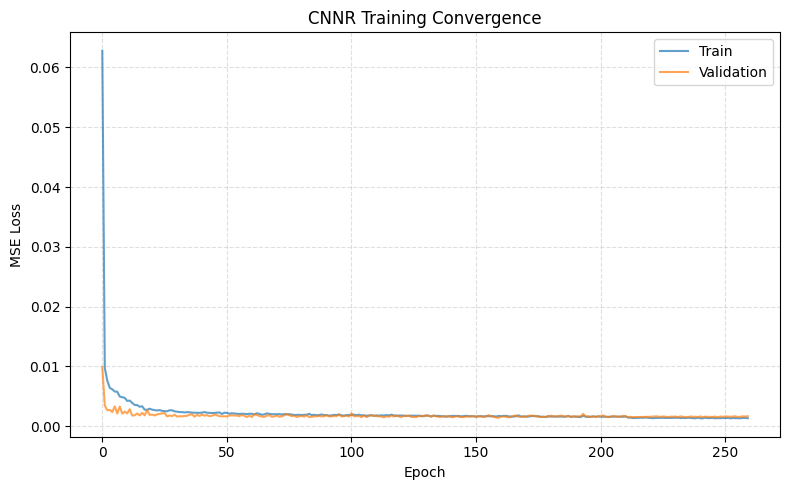


CNNR Test Results:
  RMSE    : 0.0552
  MAE     : 0.0437
  Pearson r: 0.7728
  R²      : 0.5867

Metric      Lin Reg     RF          GRNN        CNNR        
RMSE        0.0648      0.0769      0.0742      0.0552      
MAE         0.0533      0.0658      0.0657      0.0437      
Pearson r   0.7061      0.5700      0.5940      0.7728      
R²          0.4287      0.1961      0.2510      0.5867      


In [27]:
torch.manual_seed(RANDOM_STATE)

# ── CNNR Architecture (Liu et al., 2021, Figure 2) ──
class CNNR(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        # Layer 1: expand depth (1×1 conv)
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=1),
            nn.BatchNorm1d(16),
            nn.ReLU()
        )

        # Layer 2: multi-scale parallel branches (Inception-style)
        self.branch_k2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch_k3 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch_k4 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=4), nn.BatchNorm1d(32), nn.ReLU()
        )

        # Compute concatenated width after branches
        # input width = n_features, after conv1 (k=1, no padding) → n_features
        # branch k=2 → n_features-1, k=3 → n_features-2, k=4 → n_features-3
        concat_width = (n_features - 1) + (n_features - 2) + (n_features - 3)

        # Layer 3: deep feature extraction
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3), nn.BatchNorm1d(64), nn.ReLU()
        )
        width_after_conv3 = concat_width - 2

        # Layer 4: deep feature extraction
        self.conv4 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3), nn.BatchNorm1d(128), nn.ReLU()
        )
        width_after_conv4 = width_after_conv3 - 2

        # Fully connected head
        self.flatten_size = 128 * width_after_conv4
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x shape: (batch, 1, n_features)
        x = self.conv1(x)

        # Multi-scale branches
        b2 = self.branch_k2(x)
        b3 = self.branch_k3(x)
        b4 = self.branch_k4(x)
        x = torch.cat([b2, b3, b4], dim=2)   # concatenate along spatial dim

        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)            # flatten
        return self.fc(x)

n_features = len(selected_features)
cnnr = CNNR(n_features)
print(f"CNNR input features: {n_features}")
print(f"Architecture:\n{cnnr}")
print(f"Total parameters: {sum(p.numel() for p in cnnr.parameters()):,}")

# ── Prepare data ──
X_tr_t = torch.tensor(X_train_nn, dtype=torch.float32).unsqueeze(1)  # (N, 1, F)
y_tr_t = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)
X_te_t = torch.tensor(X_test_nn, dtype=torch.float32).unsqueeze(1)
y_te_t = torch.tensor(np.array(y_test), dtype=torch.float32).view(-1, 1)

# Split 15% of training as validation for early stopping
n_val = int(0.15 * len(X_tr_t))
perm = torch.randperm(len(X_tr_t), generator=torch.Generator().manual_seed(42))
val_idx, trn_idx = perm[:n_val], perm[n_val:]

train_loader = DataLoader(
    TensorDataset(X_tr_t[trn_idx], y_tr_t[trn_idx]),
    batch_size=64, shuffle=True
)
X_val_t, y_val_t = X_tr_t[val_idx], y_tr_t[val_idx]

# ── Training loop with early stopping ──
optimizer = torch.optim.Adam(cnnr.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience_counter = 0
patience_limit = 100
best_state = None
train_losses, val_losses = [], []

for epoch in range(2000):
    # Train
    cnnr.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(cnnr(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(trn_idx))

    # Validate
    cnnr.eval()
    with torch.no_grad():
        val_pred = cnnr(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in cnnr.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:4d} | train: {train_losses[-1]:.5f} | "
              f"val: {val_losses[-1]:.5f} | lr: {optimizer.param_groups[0]['lr']:.1e}")

# Restore best model
cnnr.load_state_dict(best_state)

# ── Loss curve ──
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train', alpha=0.7)
plt.plot(val_losses, label='Validation', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('CNNR Training Convergence')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Evaluate on test set ──
cnnr.eval()
with torch.no_grad():
    y_pred_cnnr = cnnr(X_te_t).numpy().ravel()

r2_cnnr      = r2_score(y_test, y_pred_cnnr)
rmse_cnnr    = np.sqrt(mean_squared_error(y_test, y_pred_cnnr))
mae_cnnr     = mean_absolute_error(y_test, y_pred_cnnr)
pearson_cnnr = np.corrcoef(y_test, y_pred_cnnr)[0, 1]

print(f"\nCNNR Test Results:")
print(f"  RMSE    : {rmse_cnnr:.4f}")
print(f"  MAE     : {mae_cnnr:.4f}")
print(f"  Pearson r: {pearson_cnnr:.4f}")
print(f"  R²      : {r2_cnnr:.4f}")

print(f"\n{'='*65}")
print(f"{'Metric':<12}{'Lin Reg':<12}{'RF':<12}{'GRNN':<12}{'CNNR':<12}")
print(f"{'='*65}")
print(f"{'RMSE':<12}{rmse_lr:<12.4f}{rmse_rf:<12.4f}{rmse_grnn:<12.4f}{rmse_cnnr:<12.4f}")
print(f"{'MAE':<12}{mae_lr:<12.4f}{mae_rf:<12.4f}{mae_grnn:<12.4f}{mae_cnnr:<12.4f}")
print(f"{'Pearson r':<12}{pearson_lr:<12.4f}{pearson_rf:<12.4f}{pearson_grnn:<12.4f}{pearson_cnnr:<12.4f}")
print(f"{'R²':<12}{r2_lr:<12.4f}{r2_rf:<12.4f}{r2_grnn:<12.4f}{r2_cnnr:<12.4f}")
print(f"{'='*65}")

### 11.4 CNNR on raw features — testing learned representation

The CNNR above received features that had already been physics-engineered. Here it
receives only raw observables : VV, VH, NDVI, sin_day, cos_day — and must learn its
own representations from scratch. This directly tests the deep-learning claim: can
learned features match hand-crafted physics?

Raw input features (5): ['VV', 'VH', 'NDVI', 'sin_day', 'cos_day']
Total parameters: 118,433
Early stopping at epoch 115


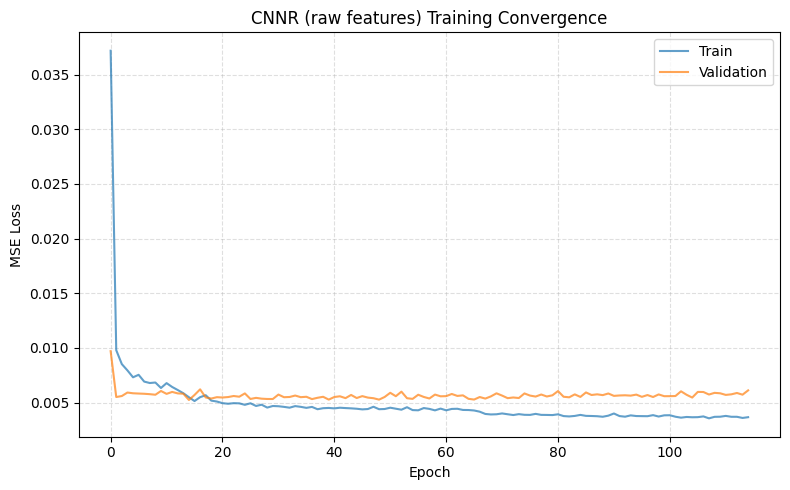


Metric      Lin Reg     RF          GRNN        CNNR+eng      CNNR+raw    
RMSE        0.0648      0.0769      0.0742      0.0552        0.0774      
MAE         0.0533      0.0658      0.0657      0.0437        0.0631      
Pearson r   0.7061      0.5700      0.5940      0.7728        0.4593      
R²          0.4287      0.1961      0.2510      0.5867        0.1859      


In [28]:
torch.manual_seed(RANDOM_STATE)

# ── Raw features only — no physics engineering ──
raw_features = ['VV', 'VH', 'NDVI', 'sin_day', 'cos_day']

X_train_raw = train[raw_features].values
X_test_raw  = test[raw_features].values

scaler_raw = StandardScaler()
X_train_raw_sc = scaler_raw.fit_transform(X_train_raw)
X_test_raw_sc  = scaler_raw.transform(X_test_raw)

n_raw = len(raw_features)
print(f"Raw input features ({n_raw}): {raw_features}")

# ── Build CNNR with raw feature dimension ──
cnnr_raw = CNNR(n_raw)
print(f"Total parameters: {sum(p.numel() for p in cnnr_raw.parameters()):,}")

# ── Prepare tensors ──
X_tr_raw_t = torch.tensor(X_train_raw_sc, dtype=torch.float32).unsqueeze(1)
y_tr_t_raw = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)
X_te_raw_t = torch.tensor(X_test_raw_sc,  dtype=torch.float32).unsqueeze(1)

# ── Same 85/15 train/val split ──
perm_r = torch.randperm(len(X_tr_raw_t),
                         generator=torch.Generator().manual_seed(42))
n_val_r   = int(0.15 * len(X_tr_raw_t))
val_r_idx = perm_r[:n_val_r]
trn_r_idx = perm_r[n_val_r:]

train_loader_raw = DataLoader(
    TensorDataset(X_tr_raw_t[trn_r_idx], y_tr_t_raw[trn_r_idx]),
    batch_size=64, shuffle=True
)
X_val_raw_t = X_tr_raw_t[val_r_idx]
y_val_raw_t = y_tr_t_raw[val_r_idx]

# ── Training loop (identical setup) ──
optimizer_r = torch.optim.Adam(cnnr_raw.parameters(),
                                lr=1e-3, weight_decay=1e-4)
scheduler_r = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_r, patience=50, factor=0.5)
criterion_r = nn.MSELoss()

best_val_r, patience_r, best_state_r = float('inf'), 0, None
train_losses_r, val_losses_r = [], []

for epoch in range(2000):
    cnnr_raw.train()
    ep_loss = 0
    for xb, yb in train_loader_raw:
        optimizer_r.zero_grad()
        loss = criterion_r(cnnr_raw(xb), yb)
        loss.backward()
        optimizer_r.step()
        ep_loss += loss.item() * len(xb)
    train_losses_r.append(ep_loss / len(trn_r_idx))

    cnnr_raw.eval()
    with torch.no_grad():
        val_loss_r = criterion_r(cnnr_raw(X_val_raw_t),
                                  y_val_raw_t).item()
    val_losses_r.append(val_loss_r)
    scheduler_r.step(val_loss_r)

    if val_loss_r < best_val_r:
        best_val_r     = val_loss_r
        patience_r     = 0
        best_state_r   = {k: v.clone()
                          for k, v in cnnr_raw.state_dict().items()}
    else:
        patience_r += 1
        if patience_r >= 100:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:4d} | train: {train_losses_r[-1]:.5f} | "
              f"val: {val_losses_r[-1]:.5f} | "
              f"lr: {optimizer_r.param_groups[0]['lr']:.1e}")

cnnr_raw.load_state_dict(best_state_r)

# ── Loss curve ──
plt.figure(figsize=(8, 5))
plt.plot(train_losses_r, label='Train', alpha=0.7)
plt.plot(val_losses_r,   label='Validation', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('CNNR (raw features) Training Convergence')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Evaluate ──
cnnr_raw.eval()
with torch.no_grad():
    y_pred_cnnr_raw = cnnr_raw(X_te_raw_t).numpy().ravel()

r2_cnnr_raw      = r2_score(y_test, y_pred_cnnr_raw)
rmse_cnnr_raw    = np.sqrt(mean_squared_error(y_test, y_pred_cnnr_raw))
mae_cnnr_raw     = mean_absolute_error(y_test, y_pred_cnnr_raw)
pearson_cnnr_raw = np.corrcoef(y_test, y_pred_cnnr_raw)[0, 1]

# ── Five-model comparison ──
print(f"\n{'='*75}")
print(f"{'Metric':<12}{'Lin Reg':<12}{'RF':<12}"
      f"{'GRNN':<12}{'CNNR+eng':<14}{'CNNR+raw':<12}")
print(f"{'='*75}")
print(f"{'RMSE':<12}{rmse_lr:<12.4f}{rmse_rf:<12.4f}"
      f"{rmse_grnn:<12.4f}{rmse_cnnr:<14.4f}{rmse_cnnr_raw:<12.4f}")
print(f"{'MAE':<12}{mae_lr:<12.4f}{mae_rf:<12.4f}"
      f"{mae_grnn:<12.4f}{mae_cnnr:<14.4f}{mae_cnnr_raw:<12.4f}")
print(f"{'Pearson r':<12}{pearson_lr:<12.4f}{pearson_rf:<12.4f}"
      f"{pearson_grnn:<12.4f}{pearson_cnnr:<14.4f}{pearson_cnnr_raw:<12.4f}")
print(f"{'R²':<12}{r2_lr:<12.4f}{r2_rf:<12.4f}"
      f"{r2_grnn:<12.4f}{r2_cnnr:<14.4f}{r2_cnnr_raw:<12.4f}")
print(f"{'='*75}")

## 12. Full Model Comparison and Discussion

All models were evaluated using the same station-grouped train-test partition. The
comparison highlights the impact of both feature engineering and model selection on
soil moisture estimation.

| Metric | Lin Reg | RF | GRNN | SVR | CNNR+eng | CNNR+raw |
|--------|---------|----|------|-----|----------|----------|
| RMSE (m³/m³) | 0.0648 | 0.0769 | 0.0742 | 0.0571 | **0.0552** | 0.0774 |
| MAE (m³/m³) | 0.0533 | 0.0658 | 0.0657 | 0.0455 | **0.0437** | 0.0631 |
| Pearson r | 0.7061 | 0.5700 | 0.5940 | 0.7587 | **0.7728** | 0.4593 |
| R² | 0.4287 | 0.1961 | 0.2510 | 0.5567 | **0.5867** | 0.1859 |